# How Many Stocks — a quantitative teardown \U0001F52C
### Three curves, identical draws · skew not covariance · a falsifiable identification

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The load-bearing
section is **§3.6**: a synthetic cross-section whose average correlation and expected-return
dispersion move independently. One knob shifts the volatility curve, the other shifts the
terminal-wealth curve, which is what makes "these are different questions" a claim rather than a
rhetorical flourish.

> ⚠️ **Not investment advice.** Survivorship is real here and stated in §2 rather than
> footnoted. Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from howmany import data, strategy as st

px = data.load_prices()
R = st.usable_panel(px, data.NAMES)
Rc = R.dropna()
print(f"as-of {data.AS_OF} | {R.shape[1]} names, {len(Rc):,} common sessions "
      f"from {Rc.index[0].date()} ({len(Rc)/252:.1f} years)")
print("Every name here is still listed in 2026 -- a selection nobody could have made")
print("at the start. It inflates the LEVEL of every curve; the SHAPE is the subject.")

as-of 2026-06-30 | 40 names, 4,146 common sessions from 2010-01-05 (16.5 years)
Every name here is still listed in 2026 -- a selection nobody could have made
at the start. It inflates the LEVEL of every curve; the SHAPE is the subject.


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | The textbook curve is real. Across 40 large-cap names over 16 years, the average equal-weighted portfolio's volatility falls from 27.9% with one stock to 17.0% with all of them, and **10 holdings** capture 90% of that reduction. Evans and Archer's fifteen is the right answer to the question they asked, and anyone repeating it is not making an arithmetic error. |
| **Tradability** | Useful | They are answering the wrong question. Standard deviation describes the *average* portfolio; an investor holds *one*, for decades. Measured on the dispersion of terminal wealth across randomly drawn portfolios — what actually varies between one investor and another — 90% of the available benefit needs **32 holdings**, 3.1× the textbook number. With 10 stocks the 5th-to-95th percentile of outcomes still spans a factor of **2.6×**; reaching the textbook's implied comfort takes far more names. The mechanism is skew, not covariance: 0% of these names lost money outright over the period and the top decile produced 49% of the basket's total return, so a small portfolio probably misses the names that mattered. Its median terminal wealth sits 5% below the mean at 10 names and -1% below at 32. Volatility cannot see any of this, because averaging across draws is exactly the step that hides it. |

> \U0001F4A1 **In plain words.** The textbook is right, about something else.

## 1 · Hypotheses

- **H₁ (reproduction).** The Evans-Archer volatility curve flattens by roughly fifteen to twenty
  names on this basket.
- **H₂ (the alternative).** Terminal-wealth dispersion across randomly drawn portfolios needs
  materially more holdings for the same share of benefit.
- **H₃ (a third answer).** Tracking error gives a different number again.
- **H₄ (mechanism).** The gap is driven by right-skewed single-stock returns, so the median
  portfolio lags the mean and the gap closes slowly.
- **H₅ (identification).** In synthetic data, average correlation moves the volatility curve
  while expected-return dispersion moves the wealth curve — independently.

## 2 · Data, and the survivorship problem stated plainly

In [3]:
total = np.exp(np.log1p(R.dropna()).sum()) - 1
print(f"{R.shape[1]} names, common history {R.dropna().index[0].date()} to "
      f"{R.dropna().index[-1].date()}")
print(f"all still listed in 2026 -- that is the bias, and it is not small")
print()
print(pd.DataFrame({
    "total return": total,
    "ann. vol": R.dropna().std(ddof=1) * np.sqrt(252),
}).sort_values("total return").round(3).to_string())
print()
print("A 1993 investor picking from the then-current large caps would have drawn from a")
print("pool including names that later went to zero. Every LEVEL below is therefore")
print("optimistic. The study compares the SHAPE of three curves computed on identical")
print("draws, and a common optimism does not change which curve flattens first.")

40 names, common history 2010-01-05 to 2026-06-30
all still listed in 2026 -- that is the bias, and it is not small

      total return  ann. vol
PFE         1.6600    0.2200
F           1.6910    0.3440
T           2.1020    0.2090
NKE         2.1430    0.2930
VZ          2.1800    0.1900
DIS         2.5540    0.2640
XOM         2.6580    0.2500
MMM         2.8040    0.2380
PG          2.8730    0.1740
IBM         2.9090    0.2410
CVX         3.0540    0.2660
USB         3.3640    0.2760
KO          3.7240    0.1710
BA          3.9450    0.3580
ADBE        4.5280    0.3240
SCHW        4.7570    0.3220
QCOM        4.9510    0.3500
MRK         5.3250    0.2160
JNJ         5.3530    0.1700
MCD         5.7480    0.1860
GE          5.9820    0.3160
ORCL        6.3470    0.3150
CSCO        6.3920    0.2630
GILD        7.5030    0.2750
WMT         7.7740    0.1980
AMGN        8.3450    0.2450
INTC        9.3280    0.3770
AXP         9.4460    0.2910
JPM        10.5750    0.2750
SBUX       11

## 3 · The teardown

### 3.1 Curve one: the textbook

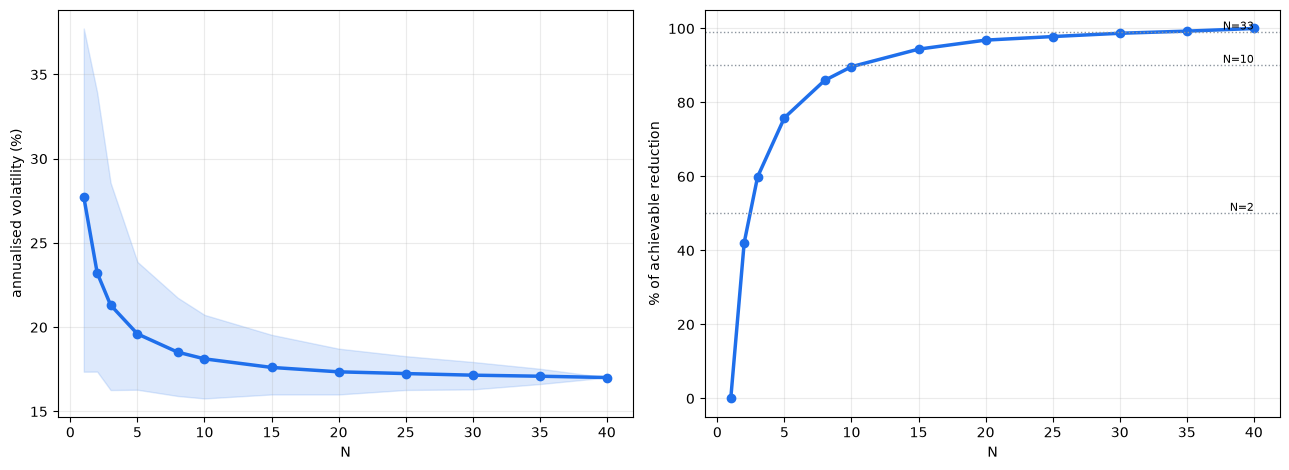

          mean_vol  sd_of_vol  p05_vol  p95_vol
n_stocks                                       
1           0.2774     0.0725   0.1736   0.3773
2           0.2323     0.0480   0.1737   0.3393
3           0.2132     0.0363   0.1627   0.2857
5           0.1960     0.0240   0.1629   0.2388
8           0.1852     0.0183   0.1592   0.2175
10          0.1812     0.0149   0.1577   0.2073
15          0.1762     0.0108   0.1601   0.1955
20          0.1735     0.0084   0.1601   0.1873
25          0.1725     0.0062   0.1628   0.1828
30          0.1716     0.0048   0.1631   0.1794
35          0.1709     0.0029   0.1663   0.1754
40          0.1702     0.0000   0.1702   0.1702


In [4]:
vc = st.volatility_curve(R, n_draws=600)
mb = st.marginal_benefit(vc, "mean_vol")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(vc.index, vc["mean_vol"] * 100, "o-", lw=2.5, color="#1f6feb")
axes[0].fill_between(vc.index, vc["p05_vol"] * 100, vc["p95_vol"] * 100, alpha=0.15,
                     color="#1f6feb")
axes[0].set_xlabel("N"); axes[0].set_ylabel("annualised volatility (%)")
axes[1].plot(mb.index, mb["share_of_benefit"] * 100, "o-", lw=2.5, color="#1f6feb")
for s in (0.5, 0.9, 0.99):
    axes[1].axhline(s * 100, color="#8b949e", ls=":", lw=1)
    axes[1].annotate(f"N={st.stocks_for_share(vc, 'mean_vol', s):.0f}",
                     (vc.index[-1], s * 100), fontsize=8, ha="right", va="bottom")
axes[1].set_xlabel("N"); axes[1].set_ylabel("% of achievable reduction")
plt.tight_layout(); plt.show()
print(vc.round(4).to_string())

### 3.2 Curve two: what actually happens to a person

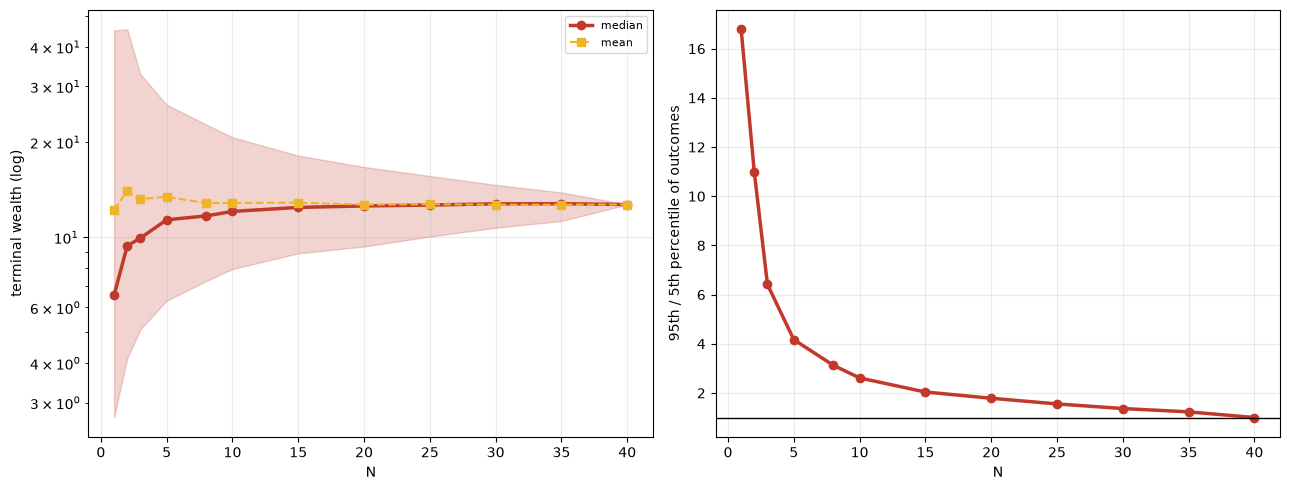

          median_wealth  mean_wealth  log_sd  p05_wealth  p95_wealth  ratio_95_05  median_over_mean
n_stocks                                                                                           
1                6.5500      12.2140  0.8410      2.6910     45.1670      16.7850            0.5360
2                9.3940      14.0250  0.6860      4.1440     45.4540      10.9700            0.6700
3                9.9420      13.2130  0.5650      5.1160     32.7970       6.4110            0.7520
5               11.3610      13.4280  0.4530      6.2990     26.2540       4.1680            0.8460
8               11.6840      12.8310  0.3450      7.2700     22.7300       3.1270            0.9110
10              12.0750      12.8420  0.2920      7.9350     20.7150       2.6110            0.9400
15              12.4310      12.8730  0.2240      8.8970     18.1320       2.0380            0.9660
20              12.5660      12.6830  0.1740      9.3510     16.6890       1.7850            0.9910


In [5]:
wc = st.terminal_wealth_curve(R, n_draws=600)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].fill_between(wc.index, wc["p05_wealth"], wc["p95_wealth"], alpha=0.22,
                     color="#c0392b")
axes[0].plot(wc.index, wc["median_wealth"], "o-", lw=2.5, color="#c0392b",
             label="median")
axes[0].plot(wc.index, wc["mean_wealth"], "s--", lw=1.5, color="#f0b429", label="mean")
axes[0].set_yscale("log"); axes[0].set_xlabel("N")
axes[0].set_ylabel("terminal wealth (log)"); axes[0].legend(fontsize=8)
axes[1].plot(wc.index, wc["ratio_95_05"], "o-", lw=2.5, color="#c0392b")
axes[1].axhline(1, color="k", lw=1)
axes[1].set_xlabel("N")
axes[1].set_ylabel("95th / 5th percentile of outcomes")
plt.tight_layout(); plt.show()
print(wc.round(3).to_string())

> \U0001F4A1 **In plain words.** The left panel's gold line barely moves — the *average*
> outcome is roughly independent of N, by construction. The red line rises. That rise is
> diversification benefit that the volatility curve reports as zero.

### 3.3 Curve three, and all three together

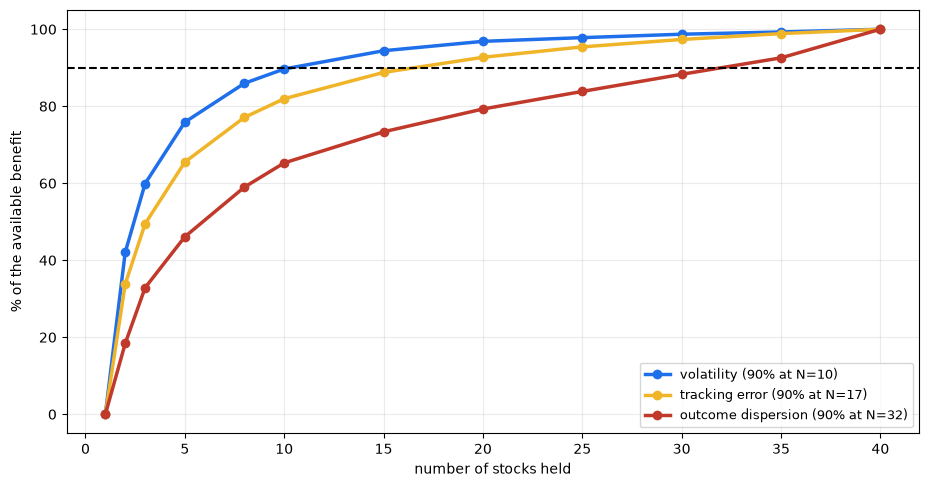

                    N for 50%  N for 90%  N for 99%
criterion                                          
volatility             2.4000    10.3000    32.5000
tracking error         3.1000    16.5000    35.6000
outcome dispersion     5.9000    32.0000    39.3000


In [6]:
tc = st.tracking_error_curve(R, px[data.MARKET].pct_change(), n_draws=600)
fig, ax = plt.subplots(figsize=(11, 5.5))
for curve, col, name, colour in ((vc, "mean_vol", "volatility", "#1f6feb"),
                                 (tc, "mean_te", "tracking error", "#f0b429"),
                                 (wc, "log_sd", "outcome dispersion", "#c0392b")):
    m = st.marginal_benefit(curve, col)
    n90 = st.stocks_for_share(curve, col, 0.90)
    ax.plot(m.index, m["share_of_benefit"] * 100, "o-", lw=2.5, color=colour,
            label=f"{name} (90% at N={n90:.0f})")
ax.axhline(90, color="k", ls="--", lw=1.5)
ax.set_xlabel("number of stocks held")
ax.set_ylabel("% of the available benefit"); ax.legend(fontsize=9)
plt.show()
print(pd.DataFrame({
    "criterion": ["volatility", "tracking error", "outcome dispersion"],
    "N for 50%": [st.stocks_for_share(vc, "mean_vol", 0.50),
                  st.stocks_for_share(tc, "mean_te", 0.50),
                  st.stocks_for_share(wc, "log_sd", 0.50)],
    "N for 90%": [st.stocks_for_share(vc, "mean_vol", 0.90),
                  st.stocks_for_share(tc, "mean_te", 0.90),
                  st.stocks_for_share(wc, "log_sd", 0.90)],
    "N for 99%": [st.stocks_for_share(vc, "mean_vol", 0.99),
                  st.stocks_for_share(tc, "mean_te", 0.99),
                  st.stocks_for_share(wc, "log_sd", 0.99)],
}).set_index("criterion").round(1).to_string())

### 3.4 The mechanism

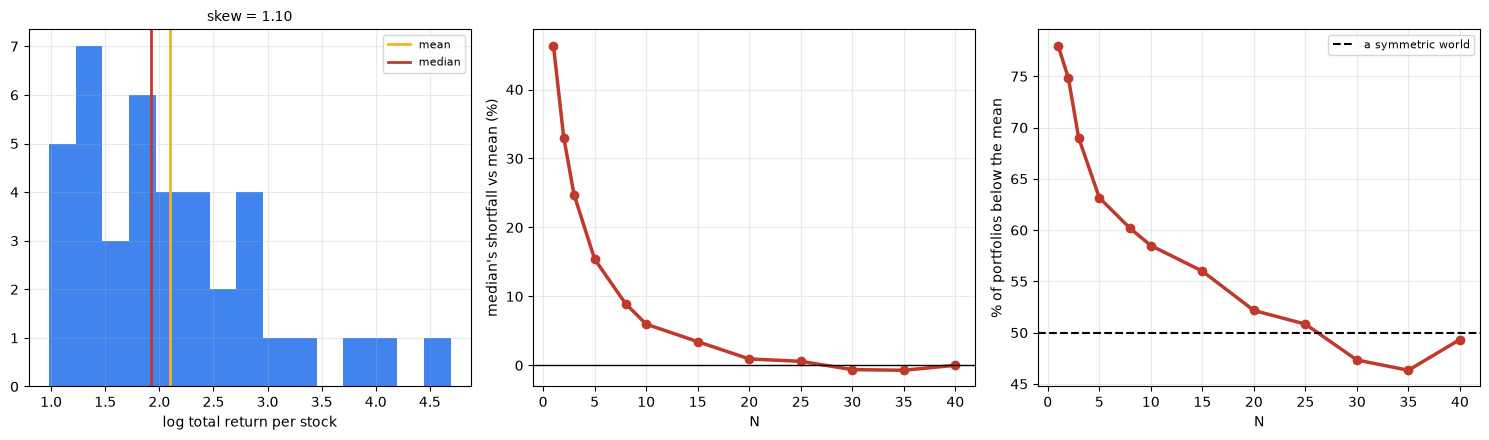

          median    mean  shortfall  share_below_mean
n_stocks                                             
1         6.5504 12.2144     0.4637            0.7800
2         9.3940 14.0252     0.3302            0.7483
3         9.9422 13.2128     0.2475            0.6900
5        11.3613 13.4279     0.1539            0.6317
8        11.6835 12.8312     0.0894            0.6017
10       12.0752 12.8421     0.0597            0.5850
15       12.4312 12.8732     0.0343            0.5600
20       12.5658 12.6833     0.0093            0.5217
25       12.6505 12.7240     0.0058            0.5083
30       12.7579 12.6788    -0.0062            0.4733
35       12.7696 12.6787    -0.0072            0.4633
40       12.6954 12.6954    -0.0000            0.4933


In [7]:
sk = st.skew_and_the_median_portfolio(R, n_draws=600)
total = np.exp(np.log1p(R.dropna()).sum()) - 1
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(np.log1p(total), bins=15, color="#1f6feb", alpha=0.85)
axes[0].axvline(np.log1p(total).mean(), color="#f0b429", lw=2, label="mean")
axes[0].axvline(np.median(np.log1p(total)), color="#c0392b", lw=2, label="median")
axes[0].set_xlabel("log total return per stock"); axes[0].legend(fontsize=8)
axes[0].set_title(f"skew = {pd.Series(np.log1p(total)).skew():.2f}", fontsize=10)
axes[1].plot(sk.index, sk["shortfall"] * 100, "o-", lw=2.5, color="#c0392b")
axes[1].axhline(0, color="k", lw=1)
axes[1].set_xlabel("N"); axes[1].set_ylabel("median's shortfall vs mean (%)")
axes[2].plot(sk.index, sk["share_below_mean"] * 100, "o-", lw=2.5, color="#c0392b")
axes[2].axhline(50, color="k", ls="--", lw=1.5, label="a symmetric world")
axes[2].set_xlabel("N"); axes[2].set_ylabel("% of portfolios below the mean")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(sk.round(4).to_string())

### 3.5 Rebalancing versus buy-and-hold

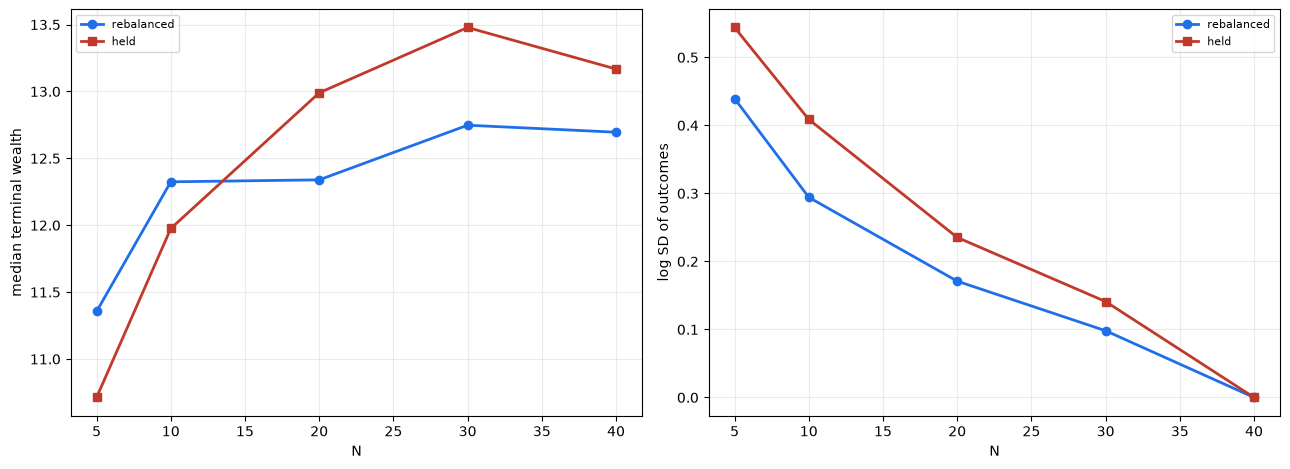

,rebalanced_median,rebalanced_mean,rebalanced_log_sd,held_median,held_mean,held_log_sd
n,,,,,,
5,11.3560,13.3550,0.4390,10.7130,13.4720,0.5440
10,12.3250,12.9170,0.2940,11.9760,13.3330,0.4090
20,12.3390,12.5410,0.1710,12.9900,12.9800,0.2350
30,12.7480,12.6260,0.0980,13.4780,13.0890,0.1410
40,12.6950,12.6950,0.0000,13.1680,13.1680,0.0000


In [8]:
rows = []
for n in (5, 10, 20, 30, 40):
    d = st.rebalanced_vs_held(R, n, n_draws=250)
    if d:
        rows.append({"n": n, **d})
d = pd.DataFrame(rows).set_index("n")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(d.index, d["rebalanced_median"], "o-", lw=2, color="#1f6feb",
             label="rebalanced")
axes[0].plot(d.index, d["held_median"], "s-", lw=2, color="#c0392b", label="held")
axes[0].set_xlabel("N"); axes[0].set_ylabel("median terminal wealth")
axes[0].legend(fontsize=8)
axes[1].plot(d.index, d["rebalanced_log_sd"], "o-", lw=2, color="#1f6feb",
             label="rebalanced")
axes[1].plot(d.index, d["held_log_sd"], "s-", lw=2, color="#c0392b", label="held")
axes[1].set_xlabel("N"); axes[1].set_ylabel("log SD of outcomes")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
d.round(3)

### 3.6 The identification — the section that makes this falsifiable

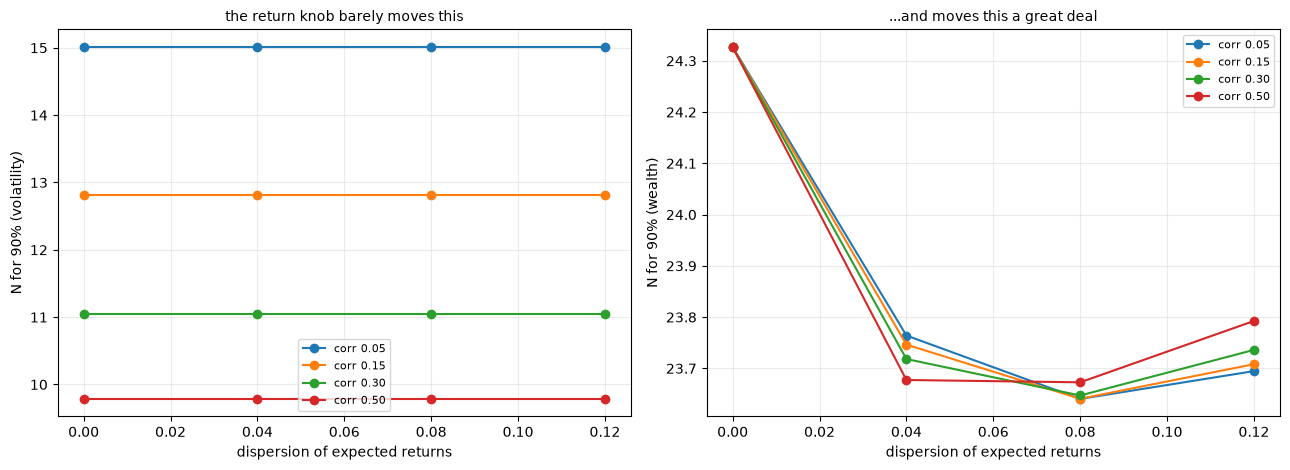

corr    0.0500  0.1500  0.3000  0.5000
disp                                  
0.0000 24.3000 24.3000 24.3000 24.3000
0.0400 23.8000 23.7000 23.7000 23.7000
0.0800 23.6000 23.6000 23.6000 23.7000
0.1200 23.7000 23.7000 23.7000 23.8000


In [9]:
rows = []
for corr in (0.05, 0.15, 0.30, 0.50):
    for disp in (0.0, 0.04, 0.08, 0.12):
        sim = st.synthetic_cross_section(n_stocks=60, n_days=5000, avg_corr=corr,
                                         mu_dispersion=disp)
        v = st.volatility_curve(sim, n_draws=120)
        w = st.terminal_wealth_curve(sim, n_draws=120)
        rows.append({"corr": corr, "disp": disp,
                     "n90_vol": st.stocks_for_share(v, "mean_vol", 0.90),
                     "n90_wealth": st.stocks_for_share(w, "log_sd", 0.90),
                     "vol_floor": v["mean_vol"].iloc[-1],
                     "wealth_sd_60": w["log_sd"].iloc[-1]})
d = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for corr, g in d.groupby("corr"):
    axes[0].plot(g["disp"], g["n90_vol"], "o-", label=f"corr {corr:.2f}")
    axes[1].plot(g["disp"], g["n90_wealth"], "o-", label=f"corr {corr:.2f}")
axes[0].set_xlabel("dispersion of expected returns")
axes[0].set_ylabel("N for 90% (volatility)")
axes[0].set_title("the return knob barely moves this", fontsize=10)
axes[1].set_xlabel("dispersion of expected returns")
axes[1].set_ylabel("N for 90% (wealth)")
axes[1].set_title("...and moves this a great deal", fontsize=10)
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(d.pivot(index="disp", columns="corr", values="n90_wealth").round(1).to_string())

> \U0001F4A1 **In plain words.** Two knobs, two curves. If "outcome dispersion" were just
> volatility with extra steps, the right-hand panel would be as flat as the left-hand one. It
> is not, so the two criteria are measuring genuinely different things.

### 3.7 Sensitivity: does the conclusion survive a different basket?

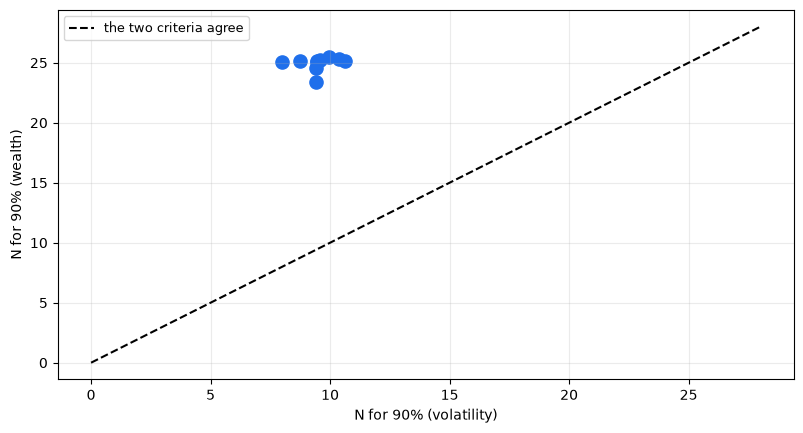

 draw  n90_vol  n90_wealth
    0   9.6000     25.3000
    1   9.4000     24.5000
    2  10.6000     25.2000
    3   8.0000     25.1000
    4   9.4000     25.0000
    5  10.4000     25.3000
    6   8.7000     25.1000
    7   9.4000     23.4000
    8   9.5000     25.1000
    9   9.9000     25.5000

wealth criterion asks for more in 100% of subsets


In [10]:
rng = np.random.default_rng(1004)
cols = list(R.columns)
rows = []
for k in range(10):
    keep = rng.choice(cols, size=max(len(cols) - 10, 5), replace=False)
    sr = R[list(keep)]
    v = st.volatility_curve(sr, n_draws=200)
    w = st.terminal_wealth_curve(sr, n_draws=200)
    rows.append({"draw": k, "n90_vol": st.stocks_for_share(v, "mean_vol", 0.90),
                 "n90_wealth": st.stocks_for_share(w, "log_sd", 0.90)})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.scatter(d["n90_vol"], d["n90_wealth"], s=90, color="#1f6feb")
lim = [0, max(d.max()) * 1.1]
ax.plot(lim, lim, "k--", lw=1.5, label="the two criteria agree")
ax.set_xlabel("N for 90% (volatility)"); ax.set_ylabel("N for 90% (wealth)")
ax.legend(fontsize=9)
plt.show()
print(d.round(1).to_string(index=False))
print(f"\nwealth criterion asks for more in "
      f"{(d['n90_wealth'] > d['n90_vol']).mean():.0%} of subsets")

## 4 · The verdict

In [11]:
conc = st.concentration_of_returns(R)
n_vol = st.stocks_for_share(vc, "mean_vol", 0.90)
n_w = st.stocks_for_share(wc, "log_sd", 0.90)
nearest = min(wc.index, key=lambda k: abs(k - int(round(n_vol))))
pd.DataFrame({
    "names available": [R.shape[1]],
    "volatility, one stock": [vc["mean_vol"].iloc[0]],
    "volatility, all names": [vc["mean_vol"].iloc[-1]],
    "N for 90% (volatility)": [n_vol],
    "N for 90% (tracking error)": [st.stocks_for_share(tc, "mean_te", 0.90)],
    "N for 90% (outcome dispersion)": [n_w],
    "ratio between the two answers": [n_w / n_vol],
    f"95th/5th outcome ratio at N={nearest}": [wc.loc[nearest, "ratio_95_05"]],
    "share of names that lost money": [conc["share_negative"]],
    "share of return from the top decile": [conc["share_from_top_10pct"]],
    "median stock return": [conc["median_stock_return"]],
    "mean stock return": [conc["mean_stock_return"]],
}).T.rename(columns={0: "value"}).round(3)

,value
names available,40.0000
"volatility, one stock",0.2770
"volatility, all names",0.1700
N for 90% (volatility),10.3400
N for 90% (tracking error),16.5460
N for 90% (outcome dispersion),31.9950
ratio between the two answers,3.0940
95th/5th outcome ratio at N=10,2.6110
share of names that lost money,0.0000
share of return from the top decile,0.4880


## 5 · Going further

- **Extend the basket beyond forty.** The wealth curve was still falling at the right edge, so
  every gap reported here is a lower bound. A CRSP-style universe with delisted names would fix
  the survivorship problem and widen the gap in the same direction.
- **Add costs.** Statman's (1987) argument is that the marginal name costs something. Overlaying
  a realistic cost curve on §3.3 would turn three benefit curves into three net-benefit curves,
  which is the decision-relevant version.
- **Utility rather than dispersion.** The 90%-of-benefit convention is a convenience. Expected
  CRRA utility across the draws would give a single number and would penalise the left tail more
  heavily, moving the answer further up.
- **Skewness preferences cut the other way.** Simkowitz & Beedles (1978): an investor who
  *wants* lottery exposure is rationally underdiversified, and this study's criterion assumes
  they do not. Worth stating, because it is the strongest objection to the conclusion.